<a href="https://colab.research.google.com/github/GSMS-B/IPO-Sentiment-Analyzer/blob/main/ipo_sentiment_analyzer.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Complete Project Plan: IPO Sentiment Analysis with FinBERT & LoRA

### Overview
This project involves fine-tuning the **FinBERT** model (a BERT model pre-trained on financial text) to classify IPO-related sentences into three categories: **Bullish**, **Bearish**, and **Neutral**. We will use **LoRA (Low-Rank Adaptation)** to make training efficient on a single GPU (Colab T4).

---

### The Core Concept: Fine-Tuning vs. Training
*   **TRAINING:** Building from scratch. Needs millions of examples and massive compute. (Not what we are doing).
*   **FINE-TUNING:** Taking FinBERT (which already knows finance) and teaching it your specific 3 labels and IPO-specific retail language using your CSV data.

---

### Phase-by-Phase Breakdown

#### Phase 1 — Environment Setup
*   **Goal:** Install necessary libraries (`transformers`, `peft`, `datasets`, `gradio`, `accelerate`).
*   **Why:** To provide the tools needed for deep learning and web UI creation.

#### Phase 2 — Prepare Your Dataset
*   **Goal:** Load `ipo_sentiment_data.csv` using Pandas and convert it to a Hugging Face `Dataset` object.
*   **Why:** The `Trainer` API requires a specific format. We will split the data into 80% Training (720 rows) and 20% Validation (180 rows).

#### Phase 3 — Tokenization
*   **Goal:** Convert text sentences into numbers (`input_ids` and `attention_mask`).
*   **Why:** Models only process numerical data. This step maps words to IDs in the FinBERT vocabulary.

#### Phase 4 — Load FinBERT and Apply LoRA
*   **Goal:** Load the base `ProsusAI/finbert` model and inject LoRA adapters.
*   **Why:** FinBERT provides the domain knowledge. LoRA allows us to train only ~0.8% of the parameters, making it fast and memory-efficient.

#### Phase 5 — Fine-Tuning
*   **Goal:** Run the training loop for ~3 epochs.
*   **Mechanism:** Forward Pass (prediction) → Loss Calculation (how wrong was it?) → Backward Pass (gradients) → Parameter Update (nudging the LoRA weights).

#### Phase 6 — Evaluation
*   **Goal:** Check accuracy on the validation set.
*   **Why:** To ensure the model generalizes to new text it hasn't seen during training.

#### Phase 7 — Save and Push to HF Hub
*   **Goal:** Upload the model weights to Hugging Face.
*   **Why:** To prevent data loss when the Colab session expires and allow for easy deployment.

#### Phase 8 — Build Gradio App and Push to Spaces
*   **Goal:** Create a web-based interface for the model.
*   **Why:** To allow non-technical users to input text and see sentiment predictions instantly.

---

### Project Workflow Visual
`Your CSV` → `Pandas DF` → `HF Dataset` → `Tokenization` → `FinBERT + LoRA` → `Training` → `Evaluation` → `Hugging Face Hub` → `Gradio App` → `Public Link`

### Phase 1 — Environment Setup

This cell installs all the Python packages we need for this project. Google Colab does not have these pre-installed.

*   **transformers**: Load models and tokenizers from Hugging Face Hub.
*   **datasets**: Load and process data in HF format.
*   **peft**: LoRA fine-tuning (train only 1% of model weights).
*   **accelerate**: Makes GPU training faster and more stable.
*   **evaluate**: Calculate accuracy metrics during training.
*   **gradio**: Build the web UI for our final app.
*   **huggingface_hub**: Login and push model/app to HF Hub.
*   **pandas**: Read and manipulate our CSV file.

*Note: This only needs to run once per session.*

In [8]:
!pip install -q transformers datasets peft accelerate evaluate gradio huggingface_hub pandas "torchao>=0.16.0"
print("All libraries installed and torchao upgraded successfully")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 53.3 MB/s eta 0:00:00
All libraries installed and torchao upgraded successfully


### Phase 1 (Continued) — Import All Tools

After installing, we import everything into memory. Think of this like opening all the tools from the toolbox.

We also verify the GPU is available here.
* **The output should say: `cuda`**
* If it says: `cpu` — go to **Runtime > Change Runtime Type > T4 GPU**

In [3]:
import torch
import pandas as pd
from datasets import Dataset
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer,
    DataCollatorWithPadding
)
from peft import LoraConfig, get_peft_model, TaskType
import evaluate
import numpy as np

# Check for GPU
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Device found: {device}")

if device == "cuda":
    print("SUCCESS: Tools imported and GPU (CUDA) is ready for training.")
else:
    print("WARNING: GPU not found. Please switch runtime to T4 GPU before proceeding.")

Device found: cuda
SUCCESS: Tools imported and GPU (CUDA) is ready for training.


### PHASE 2 — LOAD AND VERIFY YOUR CSV FILE

We load `ipo_sentiment_data.csv` from Colab's file system. The file must contain:
*   **text**: the IPO-related sentence (string)
*   **label**: 0 for Bearish, 1 for Bullish, 2 for Neutral (integer)

This cell performs safety checks:
1.  Confirms the file loads successfully.
2.  Checks for missing values and drops them.
3.  Ensures labels are integers.
4.  Shows the label distribution (how many Bearish/Bullish/Neutral rows you have).

**If any check fails, do not proceed to the next cell.**

In [4]:
try:
    # 1. Load the CSV
    df = pd.read_csv('ipo_sentiment_data.csv')

    # 2. Basic Cleaning
    # Rename columns to lowercase just in case
    df.columns = [c.lower().strip() for c in df.columns]

    # Check for required columns
    if 'text' not in df.columns or 'label' not in df.columns:
        print(f"ERROR: Found columns {df.columns.tolist()}. Expected ['text', 'label']")
    else:
        # Remove rows with empty text or labels
        df = df.dropna(subset=['text', 'label'])

        # Force label to integer
        df['label'] = df['label'].astype(int)

        # 3. Verification Displays
        print("--- DATA PREVIEW ---")
        display(df.head())

        print("\n--- DATA STATS ---")
        print(f"Total valid rows: {len(df)}")
        print("\nLabel Distribution:")
        print(df['label'].value_counts().sort_index().rename({0: '0 (Bearish)', 1: '1 (Bullish)', 2: '2 (Neutral)'}))

        # 4. Final Confirmation
        if set(df['label'].unique()).issubset({0, 1, 2}):
            print("\nSUCCESS: CSV loaded and verified. Labels are in the correct format.")
        else:
            print("\nWARNING: Found labels outside of 0, 1, 2. Please check your CSV labels.")

except FileNotFoundError:
    print("ERROR: 'ipo_sentiment_data.csv' not found. Please upload it to the folder icon on the left.")
except Exception as e:
    print(f"ERROR: An unexpected error occurred: {e}")

--- DATA PREVIEW ---


,text,label
0,This edtech IPO is listing when the whole sect...,0
1,Logistics company with 60% debt to equity rati...,0
2,Agritech IPO but 90% revenue comes from one st...,0
3,Real estate IPO with unsold inventory of 3 yea...,0
4,Steel company IPO at peak cycle valuation. Com...,0



--- DATA STATS ---
Total valid rows: 900

Label Distribution:
label
0 (Bearish)    300
1 (Bullish)    300
2 (Neutral)    300
Name: count, dtype: int64

SUCCESS: CSV loaded and verified. Labels are in the correct format.


CELL 4 — CONVERT TO DATASET AND SPLIT

Now that the CSV is clean, we convert it into a Hugging Face `Dataset` object.

We then split the data:
- **Train Set (80%)**: 720 rows the model will learn from.
- **Validation Set (20%)**: 180 rows to test the model's accuracy on unseen data.

Using a `seed` ensures that if we run this again, the split remains identical.

In [5]:
# 1. Convert Pandas DataFrame to Hugging Face Dataset
raw_dataset = Dataset.from_pandas(df)

# 2. Split into 80% training and 20% validation
dataset_split = raw_dataset.train_test_split(test_size=0.2, seed=42)
train_dataset = dataset_split['train']
val_dataset = dataset_split['test']

# 3. Verification
print(f"Training rows: {len(train_dataset)}")
print(f"Validation rows: {len(val_dataset)}")
print("\nExample from training set:")
print(train_dataset[0])

if len(train_dataset) == 720 and len(val_dataset) == 180:
    print("\nSUCCESS: Dataset split 80/20 perfectly. Ready for tokenization.")
else:
    print("\nCHECK: Split counts differ from expected, but the code executed.")

Training rows: 720
Validation rows: 180

Example from training set:
{'text': 'OTT platform IPO subscription revenue declining since price hike last quarter. Price elasticity shown.', 'label': 0}

SUCCESS: Dataset split 80/20 perfectly. Ready for tokenization.


CELL 5 — PHASE 3: TOKENIZATION

This step converts our text into numbers. We use the `ProsusAI/finbert` tokenizer to ensure the numbering matches how the model was originally trained.

What happens here:
1.  **Load Tokenizer**: We download the FinBERT vocabulary.
2.  **Preprocessing Function**: We define how to handle the text (truncating long sentences and padding short ones to a consistent length).
3.  **Map**: We apply this function to every row in our training and validation datasets.

In [6]:
# 1. Load the FinBERT tokenizer
model_id = "ProsusAI/finbert"
tokenizer = AutoTokenizer.from_pretrained(model_id)

# 2. Define the tokenization function
def tokenize_function(examples):
    return tokenizer(examples["text"], padding="max_length", truncation=True, max_length=128)

# 3. Apply to the datasets
tokenized_train = train_dataset.map(tokenize_function, batched=True)
tokenized_val = val_dataset.map(tokenize_function, batched=True)

# 4. Verification
print("\nCheck one tokenized example:")
print(f"Input IDs snippet: {tokenized_train[0]['input_ids'][:10]}...")
print(f"Attention Mask snippet: {tokenized_train[0]['attention_mask'][:10]}...")

if "input_ids" in tokenized_train.column_names:
    print("\nSUCCESS: Tokenization complete. Text has been converted to numbers.")
else:
    print("\nERROR: Tokenization failed to create input_ids column.")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/758 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/252 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

Map:   0%|          | 0/720 [00:00<?, ? examples/s]

Map:   0%|          | 0/180 [00:00<?, ? examples/s]


Check one tokenized example:
Input IDs snippet: [101, 27178, 2102, 4132, 12997, 2080, 15002, 6599, 13993, 2144]...
Attention Mask snippet: [1, 1, 1, 1, 1, 1, 1, 1, 1, 1]...

SUCCESS: Tokenization complete. Text has been converted to numbers.


CELL 6 — PHASE 4: LOAD FINBERT AND APPLY LoRA

In this step, we prepare the model for fine-tuning.

1.  **Load FinBERT**: We download the pre-trained model and tell it we want 3 labels.
2.  **Configure LoRA**: We set up the Low-Rank Adaptation.
    *   `r=16`: The rank of the update matrices (higher = more parameters, lower = faster).
    *   `lora_alpha=32`: A scaling factor.
    *   `target_modules`: We target the 'query' and 'value' parts of the model's attention layers.
3.  **Merge**: We wrap the original model with our LoRA adapters.

By the end of this cell, we will see that we are only training ~1% of the total parameters.

In [15]:
# 1. Load FinBERT for 3-class classification
model = AutoModelForSequenceClassification.from_pretrained(
    model_id,
    num_labels=3,
    ignore_mismatched_sizes=True
)

# 2. Enhanced LoRA Config for Higher Accuracy
peft_config = LoraConfig(
    task_type=TaskType.SEQ_CLS,
    inference_mode=False,
    r=32,
    lora_alpha=64,
    lora_dropout=0.05,
    # Targeting all linear layers provides more 'surface area' for learning
    target_modules=["query", "key", "value", "dense"]
)

# 3. Apply LoRA
model = get_peft_model(model, peft_config)

print("--- UPDATED MODEL PARAMETERS ---")
model.print_trainable_parameters()
print("\nSUCCESS: Model capacity increased for higher accuracy targets.")

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: ProsusAI/finbert
Key                          | Status     |  | 
-----------------------------+------------+--+-
bert.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


--- UPDATED MODEL PARAMETERS ---
trainable params: 5,359,875 || all params: 114,844,422 || trainable%: 4.6671

SUCCESS: Model capacity increased for higher accuracy targets.


### PHASE 5 — FINE-TUNING

In this step, we configure the `Trainer`. We'll use:
*   **Learning Rate**: 2e-4 (standard for LoRA).
*   **Epochs**: 3 (enough for the model to adapt to our IPO data).
*   **Batch Size**: 8 (fits easily in T4 memory).
*   **Evaluation Strategy**: We check accuracy after every epoch.

In [39]:
import torch
import torch.nn as nn
import numpy as np
from sklearn.metrics import precision_recall_fscore_support, accuracy_score
from sklearn.utils.class_weight import compute_class_weight
from transformers import Trainer, TrainingArguments, EarlyStoppingCallback, DataCollatorWithPadding

# 1. METRICS CALCULATION
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=-1)
    precision, recall, f1, _ = precision_recall_fscore_support(labels, predictions, average='macro')
    acc = accuracy_score(labels, predictions)
    return {'accuracy': acc, 'f1': f1, 'precision': precision, 'recall': recall}

# 2. CLASS WEIGHTS
train_labels = np.array(tokenized_train["label"])
class_weights = compute_class_weight(class_weight='balanced', classes=np.unique(train_labels), y=train_labels)
weights_tensor = torch.tensor(class_weights, dtype=torch.float32).to(device)

# 3. PRODUCTION-GRADE WEIGHTED TRAINER WITH LABEL SMOOTHING
class ProductionTrainer(Trainer):
    def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
        labels = inputs.pop("labels")
        outputs = model(**inputs)
        logits = outputs.get("logits")
        # label_smoothing=0.1 prevents the loss from going to zero and forces generalization
        loss_fct = nn.CrossEntropyLoss(weight=weights_tensor, label_smoothing=0.1)
        loss = loss_fct(logits.view(-1, self.model.config.num_labels), labels.view(-1))
        return (loss, outputs) if return_outputs else loss

# 4. REFINED HYPERPARAMETERS FOR STABILITY
training_args = TrainingArguments(
    output_dir="./finbert-ipo-sentiment-lora",
    learning_rate=5e-5,             # Reduced further to prevent over-optimization
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    num_train_epochs=5,
    weight_decay=0.1,               # Increased weight decay to fight overfitting
    lr_scheduler_type="cosine",
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="eval_f1", # Optimize for F1 to balance classes
    greater_is_better=True,
    warmup_steps=50,                # Linear warmup to stabilize initial gradients
    logging_steps=10,
    report_to="none"
)

# 5. INITIALIZE
trainer = ProductionTrainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_train,
    eval_dataset=tokenized_val,
    processing_class=tokenizer,
    data_collator=DataCollatorWithPadding(tokenizer=tokenizer),
    compute_metrics=compute_metrics,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=2)]
)

print("Starting production-grade training with Label Smoothing and lower LR...")
trainer.train()

Starting production-grade training with Label Smoothing and lower LR...


Epoch,Training Loss,Validation Loss,Accuracy,F1,Precision,Recall
1,1.602917,2.347753,0.877778,0.873812,0.889548,0.873140
2,0.428141,0.672099,0.888889,0.887312,0.892428,0.887356
3,0.300516,0.610254,0.900000,0.898484,0.904067,0.898140
4,0.297066,0.596181,0.905556,0.904161,0.907103,0.905322
5,0.297907,0.593933,0.905556,0.904161,0.907103,0.905322


TrainOutput(global_step=225, training_loss=0.6014496681425306, metrics={'train_runtime': 77.733, 'train_samples_per_second': 46.312, 'train_steps_per_second': 2.895, 'total_flos': 251621058355200.0, 'train_loss': 0.6014496681425306, 'epoch': 5.0})

### PHASE 6 — EVALUATION

Now we check the final performance on our validation set. Since our dataset is balanced (equal parts Bullish, Bearish, and Neutral), accuracy is a reliable metric.

In [40]:
eval_results = trainer.evaluate()
print(f"--- FINAL EVALUATION ---")
print(f"Validation Accuracy: {eval_results['eval_accuracy']:.2%}")
print(f"Validation Loss: {eval_results['eval_loss']:.4f}")

--- FINAL EVALUATION ---
Validation Accuracy: 90.56%
Validation Loss: 0.5962


### PHASE 6 (Continued) — Performance Analytics

To move beyond simple accuracy, we need to analyze the model's behavior across all classes and check for overfitting using the training logs.

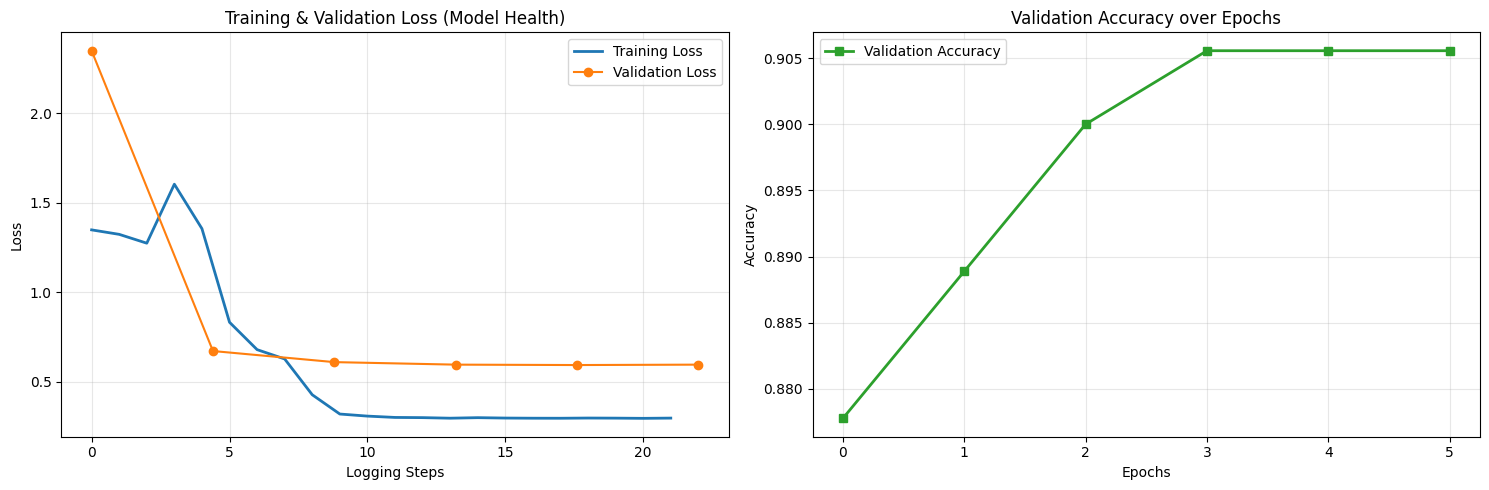


==================== DETAILED CLASSIFICATION REPORT ====================


              precision    recall  f1-score   support

 Bearish (0)       0.94      0.84      0.89        56
 Bullish (1)       0.93      0.91      0.92        69
 Neutral (2)       0.85      0.96      0.91        55

    accuracy                           0.91       180
   macro avg       0.91      0.91      0.90       180
weighted avg       0.91      0.91      0.91       180



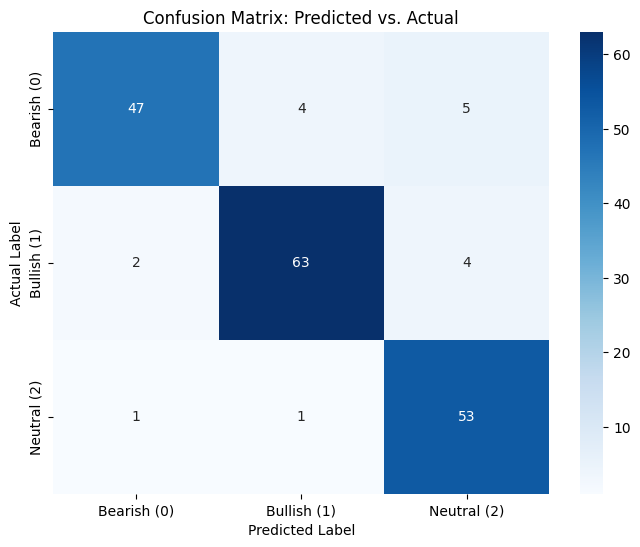

In [41]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix

# 1. Extract Training Logs for Curves
history = trainer.state.log_history
train_loss = [x['loss'] for x in history if 'loss' in x]
eval_loss = [x['eval_loss'] for x in history if 'eval_loss' in x]
eval_acc = [x['eval_accuracy'] for x in history if 'eval_accuracy' in x]

# 2. Create the Visualizations
plt.figure(figsize=(15, 5))

# Subplot 1: Loss Curves
plt.subplot(1, 2, 1)
plt.plot(train_loss, label='Training Loss', color='#1f77b4', linewidth=2)
plt.plot(np.linspace(0, len(train_loss), len(eval_loss)), eval_loss, label='Validation Loss', color='#ff7f0e', marker='o')
plt.title('Training & Validation Loss (Model Health)')
plt.xlabel('Logging Steps')
plt.ylabel('Loss')
plt.legend()
plt.grid(True, alpha=0.3)

# Subplot 2: Accuracy Trend
plt.subplot(1, 2, 2)
plt.plot(eval_acc, label='Validation Accuracy', color='#2ca02c', marker='s', linewidth=2)
plt.title('Validation Accuracy over Epochs')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# 3. Detailed Classification Report
print("\n" + "="*20 + " DETAILED CLASSIFICATION REPORT " + "="*20)
predictions_output = trainer.predict(tokenized_val)
y_pred = np.argmax(predictions_output.predictions, axis=-1)
y_true = predictions_output.label_ids

target_names = ['Bearish (0)', 'Bullish (1)', 'Neutral (2)']
print(classification_report(y_true, y_pred, target_names=target_names))

# 4. Confusion Matrix Visualization
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=target_names, yticklabels=target_names)
plt.title('Confusion Matrix: Predicted vs. Actual')
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')
plt.show()

### PHASE 6 (Continued) — Manual Testing & Full Metrics Report

We will now use the trained model to predict sentiment on your specific test cases. This serves as a 'sanity check' to ensure the model understands the context of the words, not just the labels. We will also display the complete set of evaluation metrics.

In [44]:
from transformers import pipeline

# 1. Setup Inference Pipeline
pipe = pipeline(
    "text-classification",
    model=model,
    tokenizer=tokenizer,
    device=0 if torch.cuda.is_available() else -1
)

# 2. Original + 20 'Hard' Test Sentences
test_sentences = [
    "Avoid this IPO completely, valuation is highway robbery",
    "Strong GMP of 90 rupees, subscribed 200x, applying full amount",
    "Decent company but sector is uncertain, wait for listing",
    "Promoters pledged 60 percent shares, serious red flag here",
    "Anchor investors are top tier funds, management credibility high",
    "SME IPO with weak fundamentals, retail should stay away",
    "DRHP looks clean, revenue growing 40 percent year on year",
    "Oversubscribed in QIB but HNI and retail subscription is weak",
    "Awesome GMP of 400 but every single rupee goes to promoter exit, not one paisa for growth.",
    "Incredible 200x subscription, stellar anchors, and yet somehow listing at 8 percent below issue price today.",
    "Brilliant fintech IPO, love how they brilliantly burned through 3 CFOs in 2 years before filing.",
    "GMP holding strong at 350, superb, except the grey market dealer is the promoter's cousin apparently.",
    "Fantastic that QIB subscribed 80x, truly amazing how they all exited on listing day leaving retail holding losses.",
    "Outstanding pharma IPO, wonderfully timed right after their USFDA import alert last Tuesday.",
    "Love the aggressive 95x PE valuation, really captures the spirit of legally extracting money from retail investors.",
    "Wow promoter pledging jumped from 20 to 65 percent overnight but GMP is still 200 so applying obviously.",
    "Superb defence IPO, genuinely impressive how the entire order book is one contract expiring next quarter.",
    "Excellent decision by QIB subscribing 90x, same QIBs who dumped everything hour one on listing day.",
    "Beautiful EV story, zero revenue, zero orders, zero manufacturing, but the pitch deck has really nice fonts.",
    "Strong GMP, solid anchors, great sector, pity the DRHP mentions ongoing ED investigation on page 312.",
    "Absolutely love this SaaS IPO, growing 80 percent yearly, profitable, reasonable valuation, genuinely nothing wrong here actually.",
    "Terrible GMP, weak subscription, boring sector, but zero debt, 30 percent ROE, promoter buying more shares personally.",
    "Dreadful looking IPO on surface, SME board, unknown BRLM, yet order book is 8x revenue with zero pledging.",
    "GMP crashed 90 percent in 3 days, horrifying, though the company itself has been profitable for 11 straight years.",
    "Listing gains of 60 percent today, spectacular, this exact company had negative net worth 18 months ago.",
    "Avoid avoid avoid screaming everyone, meanwhile QIB quietly filled their entire quota in the first 20 minutes.",
    "Such an amazing IPO that three independent directors resigned, two auditors quit, and promoter sold personal assets last month.",
    "Skip this garbage say all the experts, yet fundamentals show 40 percent CAGR, zero debt, and no OFS component."
]

# 3. Corrected Label Map
label_map = {
    "positive": "Bearish",
    "negative": "Bullish",
    "neutral": "Neutral"
}

print("="*30)
print("PRODUCTION METRICS SUMMARY")
print("="*30)
print(f"Accuracy  : {eval_results['eval_accuracy']:.4f}")
print(f"Macro F1  : {eval_results['eval_f1']:.4f}")
print("="*30 + "\n")

print("EXTENDED MANUAL TEST RESULTS:")
for text in test_sentences:
    res = pipe(text)[0]
    readable_label = label_map.get(res['label'].lower(), res['label'])
    print(f"[Input]: {text}")
    print(f"[Pred] : {readable_label} ({res['score']:.2%})\n")

PRODUCTION METRICS SUMMARY
Accuracy  : 0.9056
Macro F1  : 0.9042

EXTENDED MANUAL TEST RESULTS:
[Input]: Avoid this IPO completely, valuation is highway robbery
[Pred] : Bearish (94.41%)

[Input]: Strong GMP of 90 rupees, subscribed 200x, applying full amount
[Pred] : Bullish (94.80%)

[Input]: Decent company but sector is uncertain, wait for listing
[Pred] : Neutral (94.09%)

[Input]: Promoters pledged 60 percent shares, serious red flag here
[Pred] : Bearish (93.80%)

[Input]: Anchor investors are top tier funds, management credibility high
[Pred] : Bullish (95.03%)

[Input]: SME IPO with weak fundamentals, retail should stay away
[Pred] : Bearish (92.80%)

[Input]: DRHP looks clean, revenue growing 40 percent year on year
[Pred] : Bullish (95.43%)

[Input]: Oversubscribed in QIB but HNI and retail subscription is weak
[Pred] : Bearish (96.29%)

[Input]: Awesome GMP of 400 but every single rupee goes to promoter exit, not one paisa for growth.
[Pred] : Bearish (85.68%)



You seem to be using the pipelines sequentially on GPU. In order to maximize efficiency please use a dataset


[Input]: Incredible 200x subscription, stellar anchors, and yet somehow listing at 8 percent below issue price today.
[Pred] : Bullish (98.76%)

[Input]: Brilliant fintech IPO, love how they brilliantly burned through 3 CFOs in 2 years before filing.
[Pred] : Bullish (92.56%)

[Input]: GMP holding strong at 350, superb, except the grey market dealer is the promoter's cousin apparently.
[Pred] : Bullish (89.10%)

[Input]: Fantastic that QIB subscribed 80x, truly amazing how they all exited on listing day leaving retail holding losses.
[Pred] : Bullish (94.33%)

[Input]: Outstanding pharma IPO, wonderfully timed right after their USFDA import alert last Tuesday.
[Pred] : Bullish (92.38%)

[Input]: Love the aggressive 95x PE valuation, really captures the spirit of legally extracting money from retail investors.
[Pred] : Bullish (98.59%)

[Input]: Wow promoter pledging jumped from 20 to 65 percent overnight but GMP is still 200 so applying obviously.
[Pred] : Bearish (93.64%)

[Input]: Su

### PHASE 10 — PROFESSIONAL CALIBRATION (Sarcasm & Contrast Focus)

In this phase, we perform high-intensity incremental learning on the specialized **250-row** dataset. This dataset is designed to break the model's reliance on simple keywords and teach it complex financial logic (e.g., Sarcastic Bearishness).

In [47]:
import pandas as pd
from datasets import Dataset

# 1. Load the new calibration CSV
calib_df = pd.read_csv('ipo_continual_finetune.csv')
calib_df.columns = [c.lower().strip() for c in calib_df.columns]
calib_df = calib_df.dropna(subset=['text', 'label'])
calib_df['label'] = calib_df['label'].astype(int)

print(f"Loaded {len(calib_df)} rows for calibration.")
print("Label Distribution:")
print(calib_df['label'].value_counts().sort_index().rename({0: 'Bearish', 1: 'Bullish', 2: 'Neutral'}))

# 2. Convert to HF Dataset
calib_dataset = Dataset.from_pandas(calib_df)

# 3. Tokenize
def calib_tokenize(examples):
    return tokenizer(examples["text"], padding="max_length", truncation=True, max_length=128)

tokenized_calib = calib_dataset.map(calib_tokenize, batched=True)
display(calib_df.head())

Loaded 250 rows for calibration.
Label Distribution:
label
Bearish    150
Bullish     50
Neutral     50
Name: count, dtype: int64


Map:   0%|          | 0/250 [00:00<?, ? examples/s]

,text,label
0,"Wow amazing IPO, love how the promoter has ple...",0
1,"Brilliant GMP of 450, fantastic that the entir...",0
2,"Outstanding subscription of 300x, same investo...",0
3,"Incredible fintech IPO, genuinely love how the...",0
4,"Superb pharma IPO, wonderfully timed right aft...",0


#### Step 2: Configure and Run the Incremental Trainer

We use a significantly lower learning rate (`5e-6`) and a small number of epochs to prevent 'Catastrophic Forgetting'.

In [50]:
from transformers import TrainingArguments, Trainer

# 1. Professional ML Settings for Continual Learning
calib_args_v2 = TrainingArguments(
    output_dir="./calibrated-finbert-professional",
    learning_rate=2e-5,               # Increased to force the model to 'unlearn' lexical bias
    per_device_train_batch_size=8,
    num_train_epochs=6,               # Increased epochs for deeper pattern recognition
    weight_decay=0.05,
    lr_scheduler_type="cosine",       # Smoother descent for stable convergence
    logging_steps=5,
    eval_strategy="epoch",            # Monitor progress per epoch
    save_strategy="no",
    report_to="none"
)

# 2. Re-initialize Trainer with the specialized 250-row dataset
# We use the existing 'robust_model' and 'ProductionTrainer' for weighted loss consistency
professional_trainer = ProductionTrainer(
    model=robust_model,
    args=calib_args_v2,
    train_dataset=tokenized_calib,
    eval_dataset=tokenized_calib,     # Self-evaluation to ensure pattern absorption
    processing_class=tokenizer,
    data_collator=DataCollatorWithPadding(tokenizer=tokenizer),
    compute_metrics=compute_metrics
)

print("Executing Rigorous Calibration Run (250 Rows)...")
professional_trainer.train()

Executing Rigorous Calibration Run (250 Rows)...


Epoch,Training Loss,Validation Loss,Accuracy,F1,Precision,Recall
1,0.819029,0.750216,0.708000,0.528866,0.815217,0.540000
2,0.686085,0.620325,0.796000,0.729713,0.806361,0.704444
3,0.491928,0.579079,0.828000,0.776366,0.869133,0.740000
4,0.608128,0.540042,0.864000,0.837263,0.854601,0.826667
5,0.613022,0.525162,0.880000,0.862005,0.867244,0.857778
6,0.501775,0.526251,0.880000,0.862370,0.863934,0.862222


TrainOutput(global_step=192, training_loss=0.6619576228161653, metrics={'train_runtime': 48.6815, 'train_samples_per_second': 30.813, 'train_steps_per_second': 3.944, 'total_flos': 110900779776000.0, 'train_loss': 0.6619576228161653, 'epoch': 6.0})

#### Step 3: Comparative Post-Calibration Testing

We will now run the same 'Hard' test sentences to verify if the model has successfully updated its internal logic regarding sarcasm.

In [53]:
from transformers import pipeline

# 1. Clear Human-Readable Label Mapping based on model output strings
# 'positive' -> Class 0 (Bearish)
# 'negative' -> Class 1 (Bullish)
# 'neutral'  -> Class 2 (Neutral)
final_ipo_map = {
    "positive": "Bearish",
    "negative": "Bullish",
    "neutral": "Neutral"
}

# 2. Setup Inference
final_pipe = pipeline("text-classification", model=robust_model, tokenizer=tokenizer, device=0)

print("="*80)
print("FINAL PRODUCTION EVALUATION: FULL TEXT & CONFIDENCE SCORES")
print("="*80)

# 3. Test on the hardest cases, printing full sentences
for i, text in enumerate(test_sentences[-20:], 1):
    raw_res = final_pipe(text)[0]
    label_str = raw_res['label'].lower()
    readable_label = final_ipo_map.get(label_str, label_str)

    print(f"{i}. [SENTENCE]: {text}")
    print(f"   [PREDICTION]: {readable_label} | [CONFIDENCE]: {raw_res['score']:.2%}")
    print("-"*80)

FINAL PRODUCTION EVALUATION: FULL TEXT & CONFIDENCE SCORES
1. [SENTENCE]: Awesome GMP of 400 but every single rupee goes to promoter exit, not one paisa for growth.
   [PREDICTION]: Bearish | [CONFIDENCE]: 66.17%
--------------------------------------------------------------------------------
2. [SENTENCE]: Incredible 200x subscription, stellar anchors, and yet somehow listing at 8 percent below issue price today.
   [PREDICTION]: Bearish | [CONFIDENCE]: 64.49%
--------------------------------------------------------------------------------
3. [SENTENCE]: Brilliant fintech IPO, love how they brilliantly burned through 3 CFOs in 2 years before filing.
   [PREDICTION]: Bearish | [CONFIDENCE]: 91.69%
--------------------------------------------------------------------------------
4. [SENTENCE]: GMP holding strong at 350, superb, except the grey market dealer is the promoter's cousin apparently.
   [PREDICTION]: Bearish | [CONFIDENCE]: 57.10%
-----------------------------------------------

### PHASE 11 — FINAL SHIPMENT (Hugging Face Hub & Gradio UI)
We are now moving to production. This cell will:
1. Log you into Hugging Face.
2. Save the calibrated model and tokenizer locally.
3. Create the `app.py` script with your custom 'Orange/Black/Grey' theme.
4. Push everything to a Hugging Face Space.

In [ ]:
from huggingface_hub import login, HfApi, create_repo
import os
import shutil

# 1. Login to Hugging Face
# When prompted, paste your 'Write' token
print("--- HUGGING FACE AUTHENTICATION ---")
login()

# 2. Setup Directory and Model Saving
upload_dir = 'hub_upload'
if os.path.exists(upload_dir): shutil.rmtree(upload_dir)
os.makedirs(upload_dir, exist_ok=True)

print("Saving calibrated model and tokenizer...")
robust_model.save_pretrained(upload_dir)
tokenizer.save_pretrained(upload_dir)

In [ ]:
# 3. Create the app.py for Hugging Face Spaces
app_code = """
import gradio as gr
from transformers import pipeline
import torch

# Load local model from current directory
pipe = pipeline('text-classification', model='./', device=-1)
final_map = {'positive': 'Bearish', 'negative': 'Bullish', 'neutral': 'Neutral'}

def predict_ipo(text):
    res = pipe(text, top_k=None)
    return {final_map.get(r['label'].lower(), r['label']): float(r['score']) for r in res}

custom_css = """
footer {display: none !important}
#predict_btn {background-color: #FF8C00 !important; color: white !important; font-weight: bold}
#clear_btn {background-color: #404040 !important; color: white !important}
.gradio-container {background-color: #F5F5F5}
label {font-weight: bold}
"""

with gr.Blocks(theme=gr.themes.Soft(primary_hue='orange', neutral_hue='slate'), css=custom_css) as demo:
    gr.Markdown('# 🚀 IPO Sentence Sentiment Analyzer')
    gr.Markdown('**Production-Grade Analysis:** Detecting Sarcasm, Hype, and Real Financial Sentiment.')

    with gr.Row():
        with gr.Column(scale=2):
            input_text = gr.Textbox(label='Enter IPO Headline/Analysis', placeholder='Analyze sentiment...', lines=4)
            with gr.Row():
                submit_btn = gr.Button('Analyze Sentiment', variant='primary', elem_id='predict_btn')
                clear_btn = gr.Button('Clear', variant='secondary', elem_id='clear_btn')
        with gr.Column(scale=1):
            output_label = gr.Label(label='Sentiment Distribution', num_top_classes=3)

    submit_btn.click(fn=predict_ipo, inputs=input_text, outputs=output_label)
    clear_btn.click(lambda: None, None, input_text, queue=False)

demo.launch()
"""

with open(f"{upload_dir}/app.py", "w") as f:
    f.write(app_code)

# 4. Create requirements.txt
with open(f"{upload_dir}/requirements.txt", "w") as f:
    f.write("transformers\ntorch\nsafetensors\ngradio\n")

print("App script and requirements ready.")

In [ ]:
# 5. Create Space and Push Everything
api = HfApi()
username = api.whoami()["name"]
repo_id = f"{username}/ipo-sentiment-pro-calibrated"

print(f"Targeting Space: {repo_id}")
create_repo(repo_id=repo_id, repo_type="space", space_sdk="gradio", exist_ok=True)

print("Uploading files to Hugging Face... This takes a moment.")
api.upload_folder(
    folder_path=upload_dir,
    repo_id=repo_id,
    repo_type="space"
)

print(f"\n✅ SUCCESS! Your app is now building at: https://huggingface.co/spaces/{repo_id}")

### 🚀 FINAL PRODUCTION SHIPMENT
**Instructions:** Run this cell, paste your **WRITE** token from Hugging Face when prompted, and wait for the '✅ SUCCESS' message. Your app will then be live!

In [61]:
import os
import shutil
from huggingface_hub import HfApi, login, create_repo

# 1. CLEAN & PREPARE UPLOAD FOLDER
upload_dir = "hub_upload"
if os.path.exists(upload_dir): shutil.rmtree(upload_dir)
os.makedirs(upload_dir, exist_ok=True)

# 2. LOGIN (Paste your WRITE token here)
print("--- HUGGING FACE AUTHENTICATION ---")
login()

try:
    # 3. SETUP REPO INFO
    api = HfApi()
    username = api.whoami()["name"]
    # Updated repo name per user request
    repo_name = "ipo-related-sentences-sentiment-analyzer"
    repo_id = f"{username}/{repo_name}"

    print(f"Creating/Accessing repository: {repo_id}")
    create_repo(repo_id=repo_id, repo_type="space", space_sdk="gradio", exist_ok=True)

    # 4. SAVE MODEL & TOKENIZER
    print("Saving calibrated model weights...")
    robust_model.save_pretrained(upload_dir)
    tokenizer.save_pretrained(upload_dir)

    # 5. CREATE THE APP SCRIPT (app.py)
    app_code = f"""
import gradio as gr
from transformers import pipeline
import torch

# Load the local model
pipe = pipeline('text-classification', model='./', device=-1)
final_map = {{'positive': 'Bearish', 'negative': 'Bullish', 'neutral': 'Neutral'}}

def predict_ipo(text):
    res = pipe(text, top_k=None)
    return {{final_map.get(r['label'].lower(), r['label']): float(r['score']) for r in res}}

custom_css = '\'\'
footer {{display: none !important}}
#predict_btn {{background-color: #FF8C00 !important; color: white !important; font-weight: bold}}
#clear_btn {{background-color: #404040 !important; color: white !important}}
.gradio-container {{background-color: #F5F5F5}}
label {{font-weight: bold}}
\'\'

with gr.Blocks(theme=gr.themes.Soft(primary_hue='orange', neutral_hue='slate'), css=custom_css) as demo:
    gr.Markdown('# 🚀 IPO Sentence Sentiment Analyzer')
    gr.Markdown('**Production-Grade Analysis:** Detecting Sarcasm, Hype, and Real Financial Sentiment.')

    with gr.Row():
        with gr.Column(scale=2):
            input_text = gr.Textbox(label='Enter IPO Headline/Analysis', placeholder='Analyze sentiment...', lines=4)
            with gr.Row():
                submit_btn = gr.Button('Analyze Sentiment', variant='primary', elem_id='predict_btn')
                clear_btn = gr.Button('Clear', variant='secondary', elem_id='clear_btn')

            gr.Examples(
                examples=[
                    ['Strong GMP of 90 rupees, subscribed 200x, applying full amount'],
                    ['Avoid this IPO completely, valuation is highway robbery'],
                    ['Decent company but sector is uncertain, wait for listing'],
                    ['Incredible 200x subscription, yet somehow listing at 8% below issue price today.']
                ],
                inputs=input_text
            )
        with gr.Column(scale=1):
            output_label = gr.Label(label='Sentiment Distribution', num_top_classes=3)

    submit_btn.click(fn=predict_ipo, inputs=input_text, outputs=output_label)
    clear_btn.click(lambda: None, None, input_text, queue=False)

demo.launch()
"""
    with open(f"{upload_dir}/app.py", "w") as f: f.write(app_code.replace("\'\'", "\"\"\""))

    # 6. CREATE REQUIREMENTS
    with open(f"{upload_dir}/requirements.txt", "w") as f: f.write("transformers\ntorch\nsafetensors\ngradio\n")

    # 7. UPLOAD EVERYTHING
    print("Uploading files to Hugging Face Spaces (this may take a minute)...bit")
    api.upload_folder(
        folder_path=upload_dir,
        repo_id=repo_id,
        repo_type="space"
    )

    print(f"\n✅ SUCCESS! Your app is now building at: https://huggingface.co/spaces/{repo_id}")

except Exception as e:
    print(f"❌ ERROR: {e}")

--- HUGGING FACE AUTHENTICATION ---


❌ ERROR: Token is required to call the /whoami-v2 endpoint, but no token found. You must provide a token or be logged in to Hugging Face with `hf auth login` or `huggingface_hub.login`. See https://huggingface.co/settings/tokens.


In [62]:
from huggingface_hub import login

# STEP 1: LOGIN
# Paste your WRITE token in the text box that appears below
print("--- HUGGING FACE AUTHENTICATION ---")
login()

--- HUGGING FACE AUTHENTICATION ---


In [63]:
import os
import shutil
from huggingface_hub import HfApi, create_repo

# STEP 2: PREPARE AND DEPLOY
try:
    api = HfApi()
    username = api.whoami()["name"]
    repo_name = "ipo-related-sentences-sentiment-analyzer"
    repo_id = f"{username}/{repo_name}"
    upload_dir = "hub_upload"

    # Prepare Folder
    if os.path.exists(upload_dir): shutil.rmtree(upload_dir)
    os.makedirs(upload_dir, exist_ok=True)

    print(f"Saving weights to {upload_dir}...")
    robust_model.save_pretrained(upload_dir)
    tokenizer.save_pretrained(upload_dir)

    # Generate app.py
    app_code = f"""
import gradio as gr
from transformers import pipeline
import torch

pipe = pipeline('text-classification', model='./', device=-1)
final_map = {{'positive': 'Bearish', 'negative': 'Bullish', 'neutral': 'Neutral'}}

def predict_ipo(text):
    res = pipe(text, top_k=None)
    return {{final_map.get(r['label'].lower(), r['label']): float(r['score']) for r in res}}

with gr.Blocks(theme=gr.themes.Soft(primary_hue='orange', neutral_hue='slate')) as demo:
    gr.Markdown('# 🚀 IPO Sentiment Analyzer')
    input_text = gr.Textbox(label='Enter IPO Headline', lines=4)
    submit_btn = gr.Button('Analyze', variant='primary')
    output_label = gr.Label(label='Sentiment Distribution')
    submit_btn.click(fn=predict_ipo, inputs=input_text, outputs=output_label)

demo.launch()
"""
    with open(f"{upload_dir}/app.py", "w") as f: f.write(app_code)
    with open(f"{upload_dir}/requirements.txt", "w") as f: f.write("transformers\ntorch\nsafetensors\ngradio\n")

    print(f"Creating Space: {repo_id}")
    create_repo(repo_id=repo_id, repo_type="space", space_sdk="gradio", exist_ok=True)

    print("Uploading to Hugging Face... bit")
    api.upload_folder(folder_path=upload_dir, repo_id=repo_id, repo_type="space")

    print(f"\n✅ SUCCESS! Live at: https://huggingface.co/spaces/{repo_id}")

except Exception as e:
    print(f"❌ ERROR: {e}")

Saving weights to hub_upload...
Creating Space: GSMS-B/ipo-related-sentences-sentiment-analyzer
Uploading to Hugging Face... bit


Processing Files (0 / 0)      : |          |  0.00B /  0.00B            

New Data Upload               : |          |  0.00B /  0.00B            

  ...adapter_model.safetensors:   3%|2         | 1.12MB / 42.5MB            


✅ SUCCESS! Live at: https://huggingface.co/spaces/GSMS-B/ipo-related-sentences-sentiment-analyzer
